### gps track img

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.colors as mcolors  # Correct import for rgb2hex
import seaborn as sns
import os
# define here some variables:
ROOT_GPX_FILES = '/Users/filippomichelon/Documents/PersonalCode-local-utils/patagonia-trip-utils/garmin_patagonia_gpx_files'


In [3]:
# define here the function to extract .gpx files from a folder and extract it
import gpxpy
import gpxpy.gpx
import pandas as pd
import numpy as np
import os
from typing import List
from geopy.distance import geodesic  # or use haversine for faster calculation


def extract_gpx_files_from_folder(folder_path: str) -> pd.DataFrame:
    """
    Extracts multiple .gpx files from a specified folder and combines their data into a Pandas DataFrame.
    
    Parameters:
    folder_path (str): Path to the folder containing .gpx files.
    
    Returns:
    pd.DataFrame: DataFrame containing latitude, longitude, elevation, time, and file name.
    """
    data = []
    file_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.gpx')]
    
    for file_path in file_paths:
        with open(file_path, 'r') as gpx_file:
            gpx = gpxpy.parse(gpx_file)
            for track in gpx.tracks:
                for segment in track.segments:
                    for point in segment.points:
                        data.append({
                            'latitude': point.latitude,
                            'longitude': point.longitude,
                            'elevation': point.elevation,
                            'time': point.time,
                            'file': os.path.basename(file_path)
                        })
    
    return pd.DataFrame(data)

df = extract_gpx_files_from_folder(ROOT_GPX_FILES)
# sort values by date and time
df = df.sort_values('time', ascending=True).reset_index(drop=True)

# Make sure your time is datetime (optional)
df['time'] = pd.to_datetime(df['time'])

# Function to compute distance between two lat/lon points in km
def compute_distance(row1, row2):
    return geodesic((row1['latitude'], row1['longitude']),
                    (row2['latitude'], row2['longitude'])).km

# Initialize distance array
distances = [0]  # distance from start is 0

# Compute cumulative distance
for i in range(1, len(df)):
    d = compute_distance(df.iloc[i - 1], df.iloc[i])
    distances.append(distances[-1] + d)

# Add to dataframe
df['distance_km'] = distances

## filter jumps of data

In [4]:
# 1. Elevation difference
df['elev_diff'] = df['elevation'].diff()

# 2. Define conditions
drift_thresh = 0.05
df['is_flat'] = df['elev_diff'] == 0
df['is_slow'] = df['elev_diff'].abs().between(0, drift_thresh)

# 3. Group consecutive values
df['flat_group'] = (df['is_flat'] != df['is_flat'].shift()).cumsum()
df['slow_group'] = (df['is_slow'] != df['is_slow'].shift()).cumsum()

# 4. Find bad groups
flat_counts = df.groupby('flat_group')['is_flat'].sum()
slow_counts = df.groupby('slow_group')['is_slow'].sum()

bad_flat = flat_counts[flat_counts >= 50].index
bad_slow = slow_counts[slow_counts >= 50].index

# 5. Create new elevation column
df['elevation_clean'] = df['elevation']
df.loc[df['flat_group'].isin(bad_flat), 'elevation_clean'] = np.nan
df.loc[df['slow_group'].isin(bad_slow), 'elevation_clean'] = np.nan

# 6. clean from boat and km jumps
df['distance_step'] = df['distance_km'].diff().fillna(0)
df.loc[df['distance_step'] > 10, 'elevation_clean'] = np.nan



## work on plot here

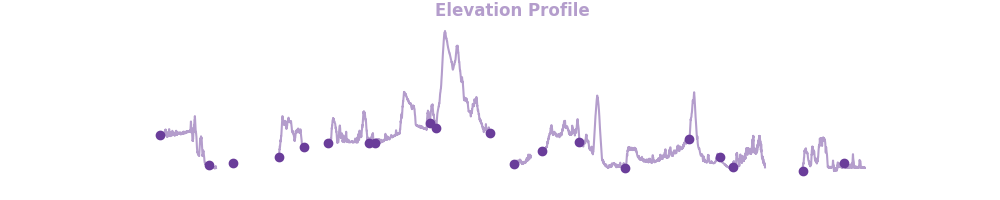

In [8]:
# get first point of every day for the scatter plot
first_points = df.groupby('file').head(1).index


plt.figure(figsize=(10, 2), facecolor='none')
hex_colors = sns.color_palette("Paired", 10).as_hex()
ax = plt.gca()

plt.plot(df.distance_km,df.elevation_clean, c = hex_colors[9], alpha = .5)     
plt.scatter (df.distance_km[first_points],df.elevation[first_points], c = hex_colors[9])

# Remove top and right border
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set spine color and width
for spine in ['bottom', 'left']:
    ax.spines[spine].set_color('white')
    ax.spines[spine].set_linewidth(1.5)

# White ticks and bold
ax.tick_params(colors='white', labelsize=10, width=1.5)
ax.xaxis.label.set_color('white')
ax.xaxis.label.set_weight('bold')
ax.yaxis.label.set_color('white')
ax.yaxis.label.set_weight('bold')

# White and bold title
plt.title('Elevation Profile', c = hex_colors[9], alpha = .5, weight='bold')

# Set labels
#plt.xlabel('Distance (km)', color='white', weight='bold')
#plt.ylabel('Elevation (m)', color='white', weight='bold')

# Make background transparent
ax.set_facecolor('none')